# A guided tour of the HMIS data quality platform

This notebook follows **one facility and one indicator** through every stage of the
pipeline, from the raw answer DHIS2 sent to the facility's data quality score.

```
DHIS2 ──extract──▶ BRONZE ──Spark──▶ SILVER ──Spark──▶ GOLD ──Spark──▶ DATA QUALITY
          raw JSON, as sent     clean, typed tables    analysis tables     findings + scores
```

Everything here is read straight from the data lake with **DuckDB**, a small SQL engine
that understands Parquet and compressed JSON. No Spark needed to *read*.

**Before running:** start Docker Desktop, then `docker compose up -d` in the project folder.
Change the three settings in the next cell to explore any other facility or indicator.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from hmis_dq.explore import gold, lake, silver

pd.set_option("display.max_colwidth", 110)
db = lake()


def q(sql, *params):
    """Run SQL against the lake and return a pandas table."""
    return db.execute(sql, list(params)).df()


FACILITY = "Ngelehun CHC"  # try "Bumpeh (Nimikoro) CHC" or "Hamilton MCHP"
INDICATOR = "Penta1 doses given"  # or "BCG doses given", "Measles doses given", ...
DATASET = "BfMAe6Itzgt"  # Child Health. Reproductive Health is "QX4ZTUbOt3a"

## 0. What's in the lake?

Three buckets, one per layer. The file names look meaningless in a browser because they're
built for machines: `.json.gz` is compressed JSON and `.parquet` is a binary column format.

In [2]:
q("""
    SELECT 'bronze' AS layer, count(*) AS files FROM glob('s3://bronze/dhis2/**')
    UNION ALL SELECT 'silver', count(*) FROM glob('s3://silver/dhis2/**')
    UNION ALL SELECT 'gold', count(*) FROM glob('s3://gold/dhis2/**')
""")

,layer,files
0,bronze,1288
1,silver,18
2,gold,144


## 1. Find the facility and the indicator

DHIS2 identifies everything by an 11-character code (a *UID*). The silver **dimension tables**
translate codes into names, and add the district and chiefdom worked out from the hierarchy.

In [3]:
facility = q(
    f"SELECT org_unit_id, name, chiefdom, district, district_id, longitude, latitude "
    f"FROM {silver('org_units')} WHERE name = ?",
    FACILITY,
)
element = q(
    f"SELECT data_element_id, name, value_type FROM {silver('data_elements')} WHERE name = ?",
    INDICATOR,
)
FACILITY_ID, DISTRICT_ID = facility.org_unit_id[0], facility.district_id[0]
ELEMENT_ID = element.data_element_id[0]
display(facility, element)

,org_unit_id,name,chiefdom,district,district_id,longitude,latitude
0,DiszpKrYNg8,Ngelehun CHC,Badjia,Bo,O6uvpzGd5pu,-11.4197,8.1039


,data_element_id,name,value_type
0,fClA2Erf6IO,Penta1 doses given,NUMBER


## 2. Bronze: exactly what DHIS2 sent

The extraction asks DHIS2 for one **dataset × district × month** at a time and stores the answer
untouched. The folder names in the key say what's inside. Each file starts with `meta`, which
records where and when it came from (its *lineage*).

In [4]:
key = (
    f"s3://bronze/dhis2/data_value_sets/dataset={DATASET}/period=202501/"
    f"org_unit={DISTRICT_ID}.json.gz"
)
print(key)
q(f"SELECT meta.* FROM read_json('{key}')")

s3://bronze/dhis2/data_value_sets/dataset=BfMAe6Itzgt/period=202501/org_unit=O6uvpzGd5pu.json.gz


,source,source_url,extracted_at,data_set,org_unit,period,record_count
0,dhis2,https://play.im.dhis2.org/stable-2-43-1,2026-10-02 13:36:46.163283,BfMAe6Itzgt,O6uvpzGd5pu,202501,934


Inside are all the district's values for the month. These are this facility's values for the
indicator: codes everywhere, and the number stored as text (`"value": "22"`). One row per
**disaggregation** (`categoryOptionCombo`), e.g. under-1s vaccinated at the facility vs. in outreach.

In [5]:
q(
    f"""
    SELECT unnest(dv) FROM (SELECT unnest(payload.dataValues) AS dv FROM read_json('{key}'))
    WHERE dv.orgUnit = ? AND dv.dataElement = ?
    """,
    FACILITY_ID,
    ELEMENT_ID,
)

,dataElement,period,orgUnit,categoryOptionCombo,attributeOptionCombo,value,storedBy,created,lastUpdated,followup
0,fClA2Erf6IO,202501,DiszpKrYNg8,Prlt0C1RF0s,HllvX50cXC0,22,bo2,2022-09-05 12:45:50,2010-03-04,False
1,fClA2Erf6IO,202501,DiszpKrYNg8,V6L425pT3A0,HllvX50cXC0,2,bo2,2022-09-05 12:45:50,2010-03-04,False


## 3. Silver: clean, typed and readable

The silver job turns text into numbers (and records *why* when it can't, in `value_status`),
dates into dates, and codes into names. Nothing is dropped.

Look at the dates: the value was **last updated in 2010, before it was created in 2022**.
That's impossible, and it's the first data quality problem we meet.

In [6]:
q(
    f"""
    SELECT v.period, c.name AS disaggregation, v.value_raw, v.value, v.value_status,
           v.created, v.last_updated
    FROM {silver("data_values")} v
    JOIN {silver("category_option_combos")} c USING (category_option_combo_id)
    WHERE v.org_unit_id = ? AND v.data_element_id = ? AND v.period = '202501'
    """,
    FACILITY_ID,
    ELEMENT_ID,
)

,period,disaggregation,value_raw,value,value_status,created,last_updated
0,202501,"Fixed, <1y",22,22.0,ok,2022-09-05 12:45:50,2010-03-04
1,202501,"Outreach, <1y",2,2.0,ok,2022-09-05 12:45:50,2010-03-04


## 4. Gold: one number per facility, indicator and month

`facility_month` adds the disaggregations together. Here is the facility's whole history,
one line per year.

**When two years' lines lie on top of each other, the values were copied from an earlier
year.** Real monthly counts never repeat this closely. At Ngelehun CHC, 2025 repeats 2023
and 2026 repeats 2024: the copy comes from *two* years back, not one.

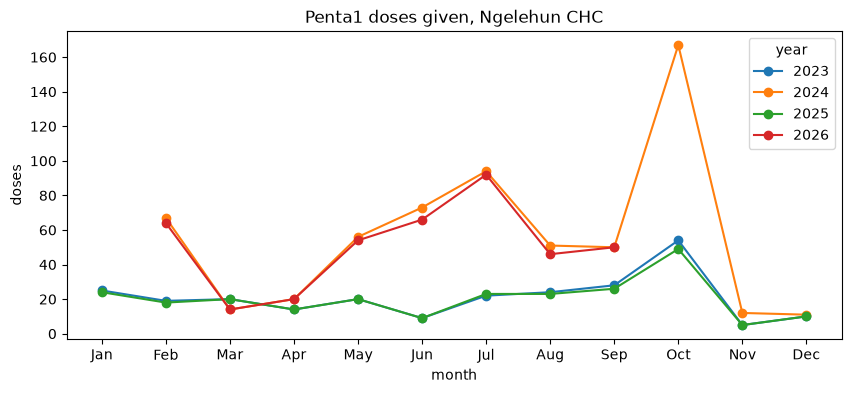

year,2023,2024,2025,2026
month,,,,
1,25.0,NaN,24.0,NaN
2,19.0,67.0,18.0,64.0
3,20.0,14.0,20.0,14.0
4,14.0,20.0,14.0,20.0
5,20.0,56.0,20.0,54.0
6,9.0,73.0,9.0,66.0
7,22.0,94.0,23.0,92.0
8,24.0,51.0,23.0,46.0
9,28.0,50.0,26.0,50.0


In [7]:
series = q(
    f"""
    SELECT year, CAST(substr(period, 5, 2) AS INTEGER) AS month, value
    FROM {gold("facility_month")}
    WHERE org_unit_id = ? AND data_element_id = ?
    ORDER BY period
    """,
    FACILITY_ID,
    ELEMENT_ID,
)
by_year = series.pivot(index="month", columns="year", values="value")

ax = by_year.plot(marker="o", figsize=(10, 4), title=f"{INDICATOR}, {FACILITY}")
ax.set_xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
)
ax.set_ylabel("doses")
plt.show()
by_year

## 5. Gold: the reports that should exist

`reporting` has one row for **every report a facility was expected to send**, whether it
arrived or not. That's what makes completeness measurable: a missing report is a row with
`reported = false`, not something silently absent.

Here is completeness for every district in this dataset.

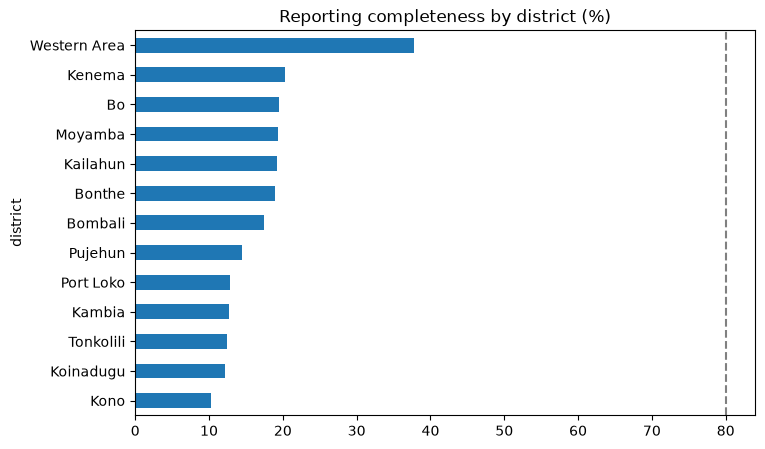

,district,expected,received,completeness
0,Kono,3825,395.0,10.3
1,Koinadugu,3150,382.0,12.1
2,Tonkolili,4185,518.0,12.4
3,Kambia,2790,353.0,12.7
4,Port Loko,4905,627.0,12.8
5,Pujehun,2925,424.0,14.5
6,Bombali,4320,756.0,17.5
7,Bonthe,2340,444.0,19.0
8,Kailahun,3465,664.0,19.2
9,Moyamba,4230,819.0,19.4


In [8]:
completeness = q(
    f"""
    SELECT district,
           count(*) AS expected,
           sum(CAST(reported AS INTEGER)) AS received,
           round(100.0 * sum(CAST(reported AS INTEGER)) / count(*), 1) AS completeness
    FROM {gold("reporting")}
    WHERE dataset_id = ?
    GROUP BY district ORDER BY completeness
    """,
    DATASET,
)
ax = completeness.plot.barh(
    x="district",
    y="completeness",
    legend=False,
    figsize=(8, 5),
    title="Reporting completeness by district (%)",
)
ax.axvline(80, color="grey", linestyle="--")  # WHO benchmark
plt.show()
completeness

## 6. Data quality: every problem, in plain language

Every check writes to one **findings** table. First the national picture, then this facility.

In [9]:
q(
    f"""
    SELECT "check", dimension,
           count(*) FILTER (WHERE severity = 'high') AS high,
           count(*) FILTER (WHERE severity = 'medium') AS medium,
           count(*) FILTER (WHERE severity = 'low') AS low
    FROM {gold("dq/findings")}
    GROUP BY ALL ORDER BY dimension, "check"
    """
)

,check,dimension,high,medium,low
0,low_reporting_completeness,completeness,78,129,0
1,never_reported,completeness,977,0,0
2,anc1_anc4_dropout,internal_consistency,0,192,0
3,penta1_penta3_dropout,internal_consistency,0,174,0
4,outlier,outliers,628,113,21619
5,entered_before_period_end,system,0,1330,0
6,last_updated_before_created,system,0,0,239
7,missing_coordinates,system,0,0,555
8,non_facility_assignment,system,0,0,5
9,repeated_values,system,200,2226,0


In [10]:
q(
    f"""
    SELECT "check", severity, period, message
    FROM {gold("dq/findings")}
    WHERE org_unit_id = ? AND dataset_id = ? AND severity != 'low'
    ORDER BY CASE severity WHEN 'high' THEN 0 ELSE 1 END, "check", period
    """,
    FACILITY_ID,
    DATASET,
)

,check,severity,period,message
0,outlier,high,202310,"Newborn protected at birth against tetanus (TT2+) = 39, typical 12 (3.5 SD from mean, modified z 4.6)"
1,outlier,high,202310,"Q_Early breastfeeding (within 1 hr after delivery) at BCG = 47, typical 13 (4.1 SD from mean, modified z 7.6)"
2,outlier,high,202402,"Penta3 doses given = 363, typical 15 (4.3 SD from mean, modified z 39.1)"
3,outlier,high,202407,"OPV0 doses given = 334, typical 26 (4.1 SD from mean, modified z 13.0)"
4,outlier,high,202410,"Penta1 doses given = 167, typical 23 (4.2 SD from mean, modified z 8.1)"
5,outlier,high,202510,"Q_Early breastfeeding (within 1 hr after delivery) at BCG = 44, typical 13 (3.7 SD from mean, modified z 7.0)"
6,outlier,high,202510,"Newborn protected at birth against tetanus (TT2+) = 39, typical 12 (3.5 SD from mean, modified z 4.6)"
7,outlier,high,202602,"Penta3 doses given = 361, typical 15 (4.3 SD from mean, modified z 38.9)"
8,outlier,high,202607,"OPV0 doses given = 325, typical 26 (4.0 SD from mean, modified z 12.6)"
9,entered_before_period_end,medium,NaN,45 of 45 reports were entered before their month ended (up to 1486 days early); timeliness can't be measured


## 7. Scores

Each dimension is `100 × (1 − share of the data affected)`, so every number can be explained:

- **completeness**: reports received ÷ expected
- **accuracy**: values not flagged as outliers
- **consistency**: years without an impossible drop-out (e.g. more Penta3 than Penta1)
- **integrity**: values not copied, not impossibly dated

The overall score is a weighted mean (35 / 25 / 20 / 20), graded A–D.

In [11]:
score_columns = "completeness, accuracy, consistency, integrity, overall, grade"
display(
    q(
        f"SELECT facility, reports_expected, reports_received, {score_columns} "
        f"FROM {gold('dq/facility_scores')} WHERE org_unit_id = ? AND dataset_id = ?",
        FACILITY_ID,
        DATASET,
    ),
    q(f"SELECT dataset_id, {score_columns} FROM {gold('dq/national_scores')} ORDER BY dataset_id"),
    q(
        f"SELECT district, {score_columns} FROM {gold('dq/district_scores')} "
        f"WHERE dataset_id = ? AND district IS NOT NULL ORDER BY overall",
        DATASET,
    ),
)

,facility,reports_expected,reports_received,completeness,accuracy,consistency,integrity,overall,grade
0,Ngelehun CHC,45,45,100.0,98.3,50.0,26.4,74.9,C


,dataset_id,completeness,accuracy,consistency,integrity,overall,grade
0,BfMAe6Itzgt,18.0,99.5,81.8,6.1,48.8,D
1,QX4ZTUbOt3a,84.1,99.5,91.3,38.8,80.3,B


,district,completeness,accuracy,consistency,integrity,overall,grade
0,Kenema,20.3,99.4,46.2,5.5,42.3,D
1,Tonkolili,12.4,99.5,77.1,4.1,45.5,D
2,Pujehun,14.5,99.6,83.3,4.0,47.4,D
3,Koinadugu,12.1,99.6,90.9,2.8,47.9,D
4,Port Loko,12.8,99.5,88.3,5.7,48.2,D
5,Kono,10.3,99.3,100.0,4.2,49.3,D
6,Kailahun,19.2,99.3,86.7,5.2,49.9,D
7,Bombali,17.5,99.6,90.8,3.7,49.9,D
8,Kambia,12.7,99.7,100.0,5.0,50.4,D
9,Moyamba,19.4,99.4,91.3,4.5,50.8,D


## 8. Your turn

- Change `FACILITY`, `INDICATOR` or `DATASET` in the first code cell, then **Run All**.
- Write your own SQL below. The helpers `silver('table')` and `gold('table')` give you any
  table: `org_units`, `data_elements`, `data_values`, `facility_month`, `reporting`,
  `district_month`, `dq/findings`, `dq/facility_scores`, `dq/district_scores`.

In [12]:
# Which facilities have the most high-severity findings?
q(
    f"""
    SELECT facility, district, count(*) AS high_findings
    FROM {gold("dq/findings")}
    WHERE severity = 'high' AND facility IS NOT NULL
    GROUP BY ALL ORDER BY high_findings DESC LIMIT 10
    """
)

,facility,district,high_findings
0,New Police Barracks CHC,Bo,32
1,Jojoima CHC,Kailahun,23
2,Gandorhun CHC,Moyamba,22
3,Ngelehun CHC,Bo,20
4,Karlu CHC,Pujehun,16
5,Senehun CHC,Moyamba,15
6,Hangha CHC,Kenema,15
7,Mayepoh CHC,Tonkolili,14
8,Yemoh Town CHC,Bo,13
9,Mano Sewallu CHP,Kailahun,13
